In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [ ]:
data = pd.read_csv('Movie dataset.csv', encoding='ISO-8859-1')

In [ ]:
data.sample(5)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
8233,Lion,(2016),118 min,"Biography, Drama",8.0,"220,526",Garth Davis,Dev Patel,Nicole Kidman,Rooney Mara
5946,Hurricane Express,(1961),NaN,Action,NaN,NaN,M.H. Doctor,Azaad Irani,Indira,Helen
9208,Mere Apne,(1971),164 min,Drama,7.4,536,Gulzar,Meena Kumari,Vinod Khanna,Shatrughan Sinha
11304,Pyari Dulhaniya,(1989),NaN,Drama,NaN,NaN,Raj N. Sippy,Arun Govil,Meera Madhuri,NaN
6261,Jaag Utha Insan,(1984),NaN,"Drama, Family",6.2,69,K. Viswanath,Mithun Chakraborty,Sridevi,Rakesh Roshan


In [ ]:
data.shape

(15509, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
data.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [ ]:
data.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [ ]:
data['Genre'] = data['Genre'].fillna('Unknown')
data['Director'] = data['Director'].fillna('Unknown')
data['Actor 1'] = data['Actor 1'].fillna('Unknown')
data['Actor 2'] = data['Actor 2'].fillna('Unknown')
data['Actor 3'] = data['Actor 3'].fillna('Unknown')

In [ ]:
data.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,0
Rating,7590
Votes,7589
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [ ]:
data['Rating'] = data['Rating'].fillna(data['Rating'].median())

In [ ]:
data['Rating'].sort_values(ascending = False)

,Rating
8339,10.0
5410,9.7
2563,9.6
6852,9.4
14222,9.4
...,...
9639,1.6
6744,1.6
15040,1.6
3618,1.4


In [ ]:
data.sample(20)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
178,Aa Dekhen Zara,(2009),117 min,"Action, Sci-Fi, Thriller",5.0,866,Jehangir Surti,Neil Nitin Mukesh,Bipasha Basu,Sophiya Chaudhary
2561,Breakup,(2018),NaN,Romance,6.0,NaN,Munna Rizvi,Sahil Akhtar,Kuwar Aziz,Sheetal Kale
2907,Chatayi Kahan Bhichayun,(2015),NaN,Romance,6.0,NaN,Param Sivan,Aswin Prasad,Rahul Rajan,Sandeep Shah
10115,Nazrana,(1978),NaN,Drama,6.0,NaN,Unknown,Unknown,Unknown,Unknown
12134,Sab Se Badi Adalat,(1987),NaN,Drama,6.0,NaN,Surinder Suri,Vijayendra Ghatge,Simple Kapadia,Bharat Kapoor
3462,Darogaji,(1949),123 min,"Crime, Drama, Romance",7.7,9,Akhtar Hussein,Nargis,Paidi Jairaj,Rashid Khan
15488,Zoo,(2018),100 min,Drama,5.7,78,Shlok Sharma,Shashank Arora,Prince Daniel,Shatakshi Gupta
282,Aaj Ka Daur,(1985),153 min,"Action, Drama",5.1,40,K. Bapaiah,Jackie Shroff,Padmini Kolhapure,Nirupa Roy
492,Aasmaan,(1984),145 min,"Drama, Mystery",4.8,12,Tony Juneja,Rajiv Kapoor,Divya Rana,Tina Ambani
14296,The Women in Blue Berets,(2012),48 min,Documentary,6.0,NaN,Farida Pacha,Unknown,Unknown,Unknown


In [ ]:
# remove commas from Votes column and convert to integer
data['Votes'] = data['Votes'].astype(str).str.replace(',', '',regex = False)
data['Votes'] = pd.to_numeric(data['Votes'], errors='coerce')

In [ ]:
data.describe()

,Rating,Votes
count,15509.000000,7919.000000
mean,5.919131,1938.520394
std,0.990512,11602.415952
min,1.100000,5.000000
25%,6.000000,16.000000
50%,6.000000,55.000000
75%,6.000000,404.000000
max,10.000000,591417.000000


In [ ]:
# outliers in votes so we will use median
data['Votes'] = data['Votes'].fillna(data['Votes'].median())

In [ ]:
data.isnull().sum()


,0
Name,0
Year,528
Duration,8269
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [ ]:
data['Duration'] = data['Duration'].astype(str).str.replace('min', '',regex = False)
data['Duration'] = pd.to_numeric(data['Duration'], errors='coerce')

In [ ]:
data.Duration.count()

np.int64(7240)

In [ ]:
data.Duration.nunique()

182

In [ ]:
data.describe()

,Duration,Rating,Votes
count,7240.000000,15509.000000,15509.000000
mean,128.126519,5.919131,1016.738217
std,28.912724,0.990512,8343.751448
min,2.000000,1.100000,5.000000
25%,110.000000,6.000000,52.000000
50%,131.000000,6.000000,55.000000
75%,147.000000,6.000000,59.000000
max,321.000000,10.000000,591417.000000


<Axes: >

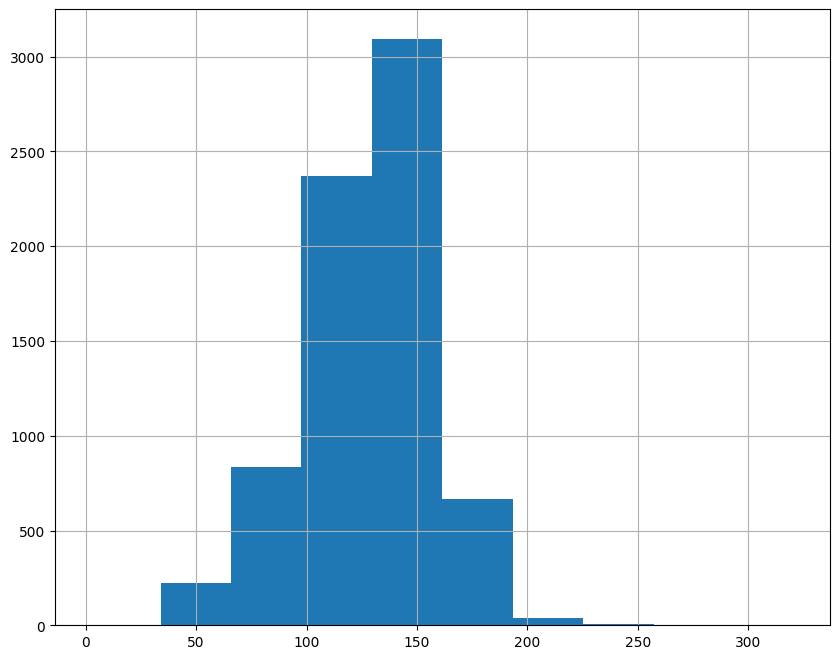

In [ ]:
data['Duration'].hist(bins = 10, figsize = (10,8))

In [ ]:
data['Genre'].nunique()

486

In [ ]:
genre_count = data['Genre'].value_counts()

In [ ]:
(genre_count > 50).sum()

np.int64(41)

In [ ]:
freq = data['Genre'].value_counts()
valid_genres = freq[freq >= 50].index

data['Genre'] = data['Genre'].apply(
    lambda x: x if x in valid_genres else 'Other'
)

In [ ]:
data.groupby('Genre')['Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Genre,,,,,,,,
Action,262.0,130.637405,26.626015,46.0,118.00,133.0,141.00,300.0
"Action, Adventure, Drama",47.0,143.723404,21.190340,90.0,131.00,142.0,153.50,193.0
"Action, Comedy, Crime",77.0,141.753247,29.221547,92.0,128.00,138.0,156.00,321.0
"Action, Comedy, Drama",119.0,150.487395,18.308961,97.0,138.50,150.0,162.00,199.0
"Action, Crime, Drama",343.0,140.967930,21.522642,57.0,127.00,142.0,155.00,223.0
"Action, Crime, Thriller",46.0,139.826087,19.758885,91.0,126.50,141.5,152.75,172.0
"Action, Drama",217.0,145.622120,22.328670,45.0,134.00,146.0,159.00,214.0
"Action, Drama, Romance",108.0,152.740741,20.031457,91.0,140.75,154.0,168.00,213.0
"Action, Drama, Thriller",55.0,140.800000,31.006809,46.0,135.00,143.0,155.00,192.0


In [ ]:
from scipy.stats import f_oneway

groups = [group['Duration'].dropna() for name, group in data.groupby('Genre')]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(41.4048861439702), pvalue=np.float64(4.398741273497966e-294))


#### Groupby shows descriptive differences in mean duration across genres, while ANOVA statistically tests whether those differences are significant rather than due to random variation.

In [ ]:
data['Duration'] = data.groupby('Genre')['Duration'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
data.dropna(subset = ['Year'],inplace = True)

In [ ]:
data.isnull().sum()


,0
Name,0
Year,0
Duration,0
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [ ]:
data.shape

(14981, 10)

## EDA

In [ ]:
# Combine all actor columns into a single Series
# Remove rows where any actor is 'Unknown'
data = data[
    (data['Actor 1'] != 'Unknown') &
    (data['Actor 2'] != 'Unknown') &
    (data['Actor 3'] != 'Unknown')
]
all_actors = pd.concat([data['Actor 1'], data['Actor 2'],data['Actor 3']])
# Count appearances of each actor
actor_counts = all_actors.value_counts()
top_10_actors = actor_counts.head(10)
print(top_10_actors)



Mithun Chakraborty    240
Dharmendra            229
Ashok Kumar           225
Jeetendra             179
Amitabh Bachchan      171
Rekha                 142
Rajesh Khanna         137
Shashi Kapoor         133
Shatrughan Sinha      129
Raj Babbar            127
Name: count, dtype: int64


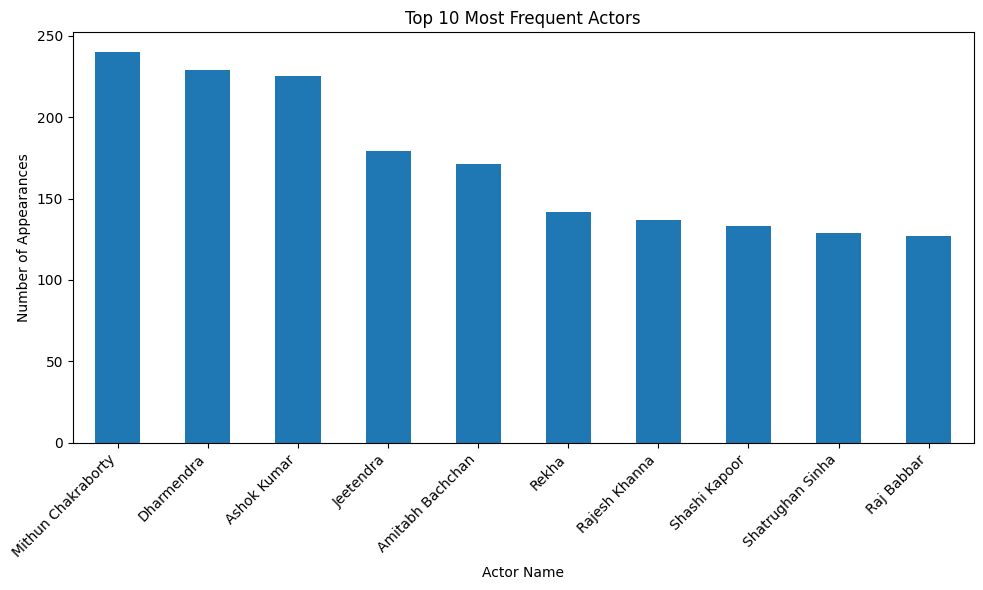

In [ ]:
# Plotting the top 10 actors
plt.figure(figsize=(10, 6))
top_10_actors.plot(kind='bar')

plt.title('Top 10 Most Frequent Actors')
plt.xlabel('Actor Name')
plt.ylabel('Number of Appearances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# top 10 movies based on rating
top_movie = data.loc[data['Rating'].sort_values(ascending=False)[:10].index]
top_movie

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
8339,Love Qubool Hai,(2020),94.0,"Drama, Romance",10.0,5.0,Saif Ali Sayeed,Ahaan Jha,Mahesh Narayan,Rajasree Rajakumari
5410,Half Songs,(2021),79.0,Other,9.7,7.0,Sriram Raja,Raj Banerjee,Emon Chatterjee,Purshottam Mulani
2563,Breed,(2020),121.0,Drama,9.6,48.0,Bobby Kumar,Bobby Kumar,Ashfaq,Fasih Choudhry
6852,June,(2021),93.0,Drama,9.4,18.0,Suhrud Godbole,Vaibhav Khisti,Nilesh Divekar,Jitendra Joshi
5077,Gho Gho Rani,(2019),105.0,Other,9.4,47.0,Munni Pankaj,Nishi Neha Mishra,Pankaj Kamal,Akash Kumar
14222,The Reluctant Crime,(2020),113.0,Drama,9.4,16.0,Arvind Pratap,Dharmendra Ahir,Awanish Kotnal,Rakhi Mansha
1729,Baikunth,(2021),72.0,Family,9.3,29.0,Vishwa Bhanu,Vishwa Bhanu,Sangam Shukla,Vijay Thakur
5125,God of gods,(2019),90.0,Documentary,9.3,46.0,Venkatesh Bk,Tejaswini Manogna,Triyug Mantri,Raj Singh Verma
12673,Secrets of Sinauli,(2021),56.0,Other,9.3,1373.0,Raghav Jairath,Manoj Bajpayee,R.S. Bhist,K.N. Dixit
9105,Meher,(2020),121.0,Drama,9.3,27.0,Rajat Bhardwaj,Amrit,Dimple Chauhan,Sapna Das


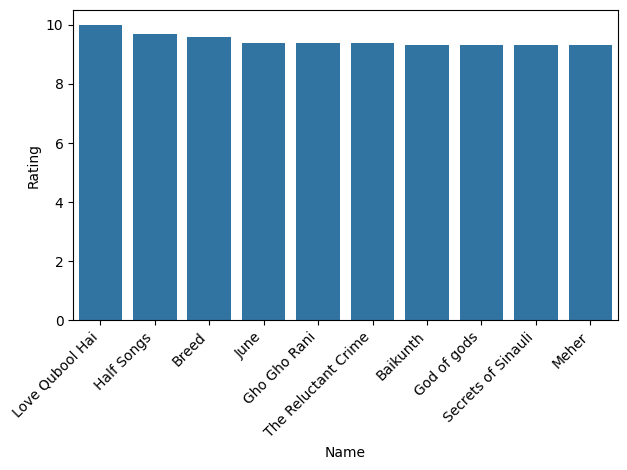

In [ ]:
sns.barplot(x = 'Name', y ='Rating', data = top_movie )
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# top 10 genres
genre_counts = data['Genre'].value_counts()
top_10_genres = genre_counts.head(10)
print(top_10_genres)

Genre
Other                   2139
Drama                   2116
Action                   991
Unknown                  988
Drama, Romance           507
Romance                  504
Action, Crime, Drama     452
Drama, Family            405
Thriller                 404
Comedy                   401
Name: count, dtype: int64


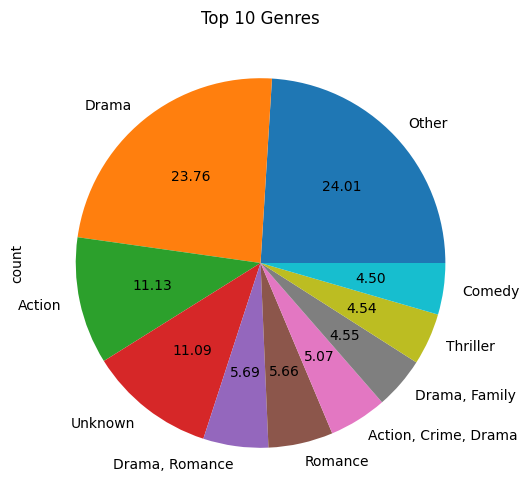

In [ ]:
# Plotting the top 10 genres
plt.figure(figsize=(10, 6))
top_10_genres.plot(kind='pie',autopct = '%0.2f')
plt.title('Top 10 Genres')
plt.show()

In [ ]:
# Distribution of number of movie released every year
data['Year'] = data['Year'].astype(str)
data['Year'] = data['Year'].str.extract(r'(\d{4})').astype(int)
yearly_movie_counts = data['Year'].value_counts().reset_index()
yearly_movie_counts.columns = ['Year', 'MovieCount']
yearly_movie_counts = yearly_movie_counts.sort_values(by='Year')
yearly_movie_counts

,Year,MovieCount
93,1915,1
94,1917,1
92,1928,2
95,1930,1
90,1931,20
...,...,...
2,2018,304
0,2019,350
4,2020,263
1,2021,321


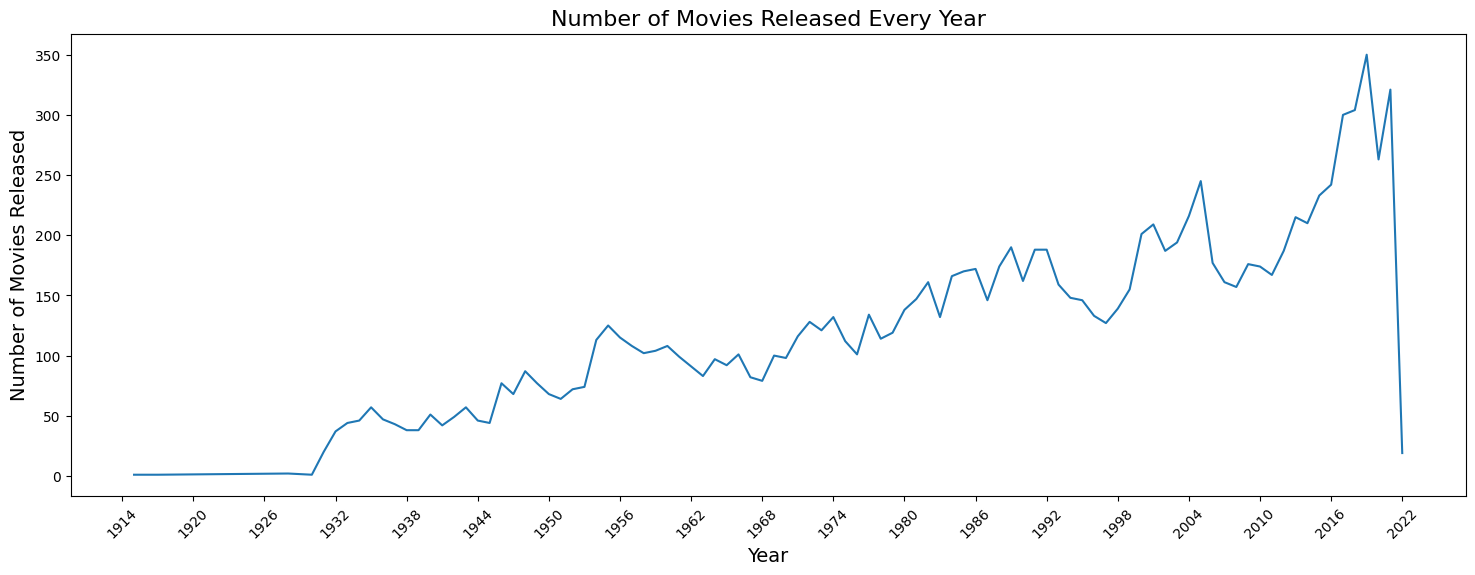

In [ ]:
from matplotlib.ticker import MaxNLocator
plt.figure(figsize=(18, 6))
sns.lineplot(data=yearly_movie_counts, x='Year', y='MovieCount')
plt.title('Number of Movies Released Every Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Movies Released', fontsize=14)
plt.xticks(rotation=45)
years = yearly_movie_counts['Year']
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True,nbins = 20))
plt.show()

In [ ]:
# Distribution of Top directors by average rating

# Group the data by director and calculate the average rating
director_avg_rating = data.groupby('Director')['Rating'].mean().reset_index()

director_avg_rating = director_avg_rating.sort_values(by='Rating', ascending=False)

top_directors = director_avg_rating.head(10)
top_directors

,Director,Rating
3600,Saif Ali Sayeed,10.0
4092,Sriram Raja,9.7
809,Bobby Kumar,9.6
4153,Suhrud Godbole,9.4
521,Arvind Pratap,9.4
2434,Munni Pankaj,9.4
3029,Rahul Mallick,9.3
3739,Sapna Bhavnani,9.3
1236,Gautam Joshi,9.3
3005,Raghav Jairath,9.3


In [ ]:
# Distribution of Top actors by average rating

# Group the data by actor and calculate the average rating
actor_avg_rating = data.groupby('Actor 1')['Rating'].mean().reset_index()

actor_avg_rating = actor_avg_rating.sort_values(by='Rating', ascending=False)

top_actors = actor_avg_rating.head(10)
top_actors

,Actor 1,Rating
120,Ahaan Jha,10.0
2621,Raj Banerjee,9.7
1002,Dharmendra Ahir,9.4
2323,Nishi Neha Mishra,9.4
3735,Vaibhav Khisti,9.4
3797,Vijay Mahar,9.3
3645,Tejaswini Manogna,9.3
305,Amrit,9.3
1791,Leila Advani,9.3
2481,Prashant Chaubey,9.3


In [ ]:
data['duration_bin'] = pd.cut(
    data['Duration'],
    bins=[0, 90, 120, 150, 310],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

In [ ]:
data = data.drop(['Name','Duration'],axis = 1)

In [ ]:
data['Actor 1'].nunique()

3980

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
# Transform Director columns
data['Director'] = labelencoder.fit_transform(data['Director'])

# Transform Actors Columns
data['Actor 1'] = labelencoder.fit_transform(data['Actor 1'])
data['Actor 2'] = labelencoder.fit_transform(data['Actor 2'])
data['Actor 3'] = labelencoder.fit_transform(data['Actor 3'])

data['Genre'] = labelencoder.fit_transform(data['Genre'].apply(lambda x: ','.join(x)))
data['duration_bin'] = labelencoder.fit_transform(data['duration_bin'])

data.head()

,Year,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,duration_bin
1,2019,25,7.0,8.0,1227,2797,4330,510,1
2,2021,38,6.0,55.0,4069,3154,2630,3329,2
3,2019,19,4.4,35.0,2638,2493,1381,3875,1
4,2010,25,6.0,55.0,312,2657,3174,392,1
5,1997,17,4.7,827.0,3032,792,112,3690,0


In [ ]:
 from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
sc_data = scaler.fit_transform(data)
sc_df = pd.DataFrame(sc_data,columns=data.columns)

sc_df.head()

,Year,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,duration_bin
0,0.971963,0.609756,0.662921,0.000005,0.260068,0.702940,0.980303,0.109819,0.25
1,0.990654,0.926829,0.550562,0.000085,0.862442,0.792661,0.595427,0.716839,0.50
2,0.971963,0.463415,0.370787,0.000051,0.559135,0.626539,0.312656,0.834410,0.25
3,0.887850,0.609756,0.550562,0.000085,0.066130,0.667756,0.718587,0.084410,0.25
4,0.766355,0.414634,0.404494,0.001390,0.642645,0.199045,0.025357,0.794574,0.00


In [ ]:
corr_df = data.corr(numeric_only=True)
corr_df['Rating'].sort_values(ascending=False)

,Rating
Rating,1.000000
Votes,0.124256
Genre,0.091898
duration_bin,0.054238
Actor 2,0.026085
Actor 3,0.025938
Actor 1,0.016053
Director,-0.006972
Year,-0.152272


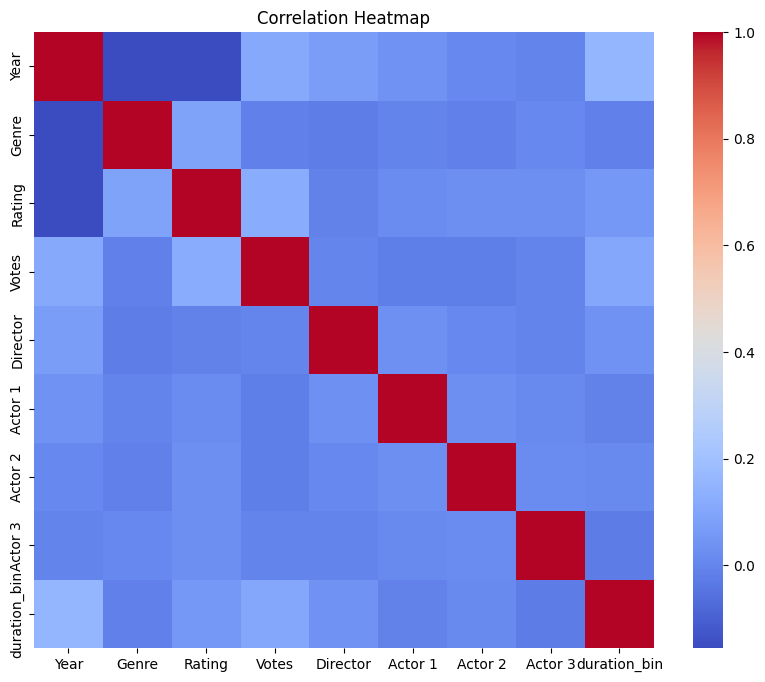

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df,annot=False,cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = data.drop(['Rating'],axis=1)
y = data['Rating']




X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)




# Initialize models
lr = LinearRegression()


# Train models
lr.fit(X_train, y_train)



LinearRegression()

In [ ]:
y_pred_test = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

In [ ]:
print("Linear Regression Metrics:")
print("Mean Squared Error_test:", mean_squared_error(y_test, y_pred_test))
print("Mean Squared Error_train:", mean_squared_error(y_train, y_pred_train))
print("Mean Absolute Error_test:", mean_absolute_error(y_test, y_pred_test))
print("Mean Absolute Error_train:", mean_absolute_error(y_train, y_pred_train))
print("R-squared:", r2_score(y_test, y_pred_test))

Linear Regression Metrics:
Mean Squared Error_test: 1.113149779774501
Mean Squared Error_train: 1.1349020334481712
Mean Absolute Error_test: 0.7331981661889716
Mean Absolute Error_train: 0.750799992371334
R-squared: 0.012193310765814203


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
rf = RandomForestRegressor(n_estimators = 300, max_depth = 300, min_samples_leaf = 5, min_samples_split = 10, random_state = 42)
rf.fit(X_train, y_train)
y_pred_rf_test = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)
print("Random forest Metrics:")
print("Mean Squared Error_test:", mean_squared_error(y_test, y_pred_rf_test))
print("Mean Squared Error_train:", mean_squared_error(y_train, y_pred_rf_train))
print("Mean Absolute Error_test:", mean_absolute_error(y_test, y_pred_rf_test))
print("Mean Absolute Error_train:", mean_absolute_error(y_train, y_pred_rf_train))
print("R-squared:", r2_score(y_test, y_pred_rf_test))


Random forest Metrics:
Mean Squared Error_test: 0.7725202370870862
Mean Squared Error_train: 0.36159662165533846
Mean Absolute Error_test: 0.5285890742921927
Mean Absolute Error_train: 0.35798459557814183
R-squared: 0.31446722478084665


In [ ]:
RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42
)

In [ ]:
gb = GradientBoostingRegressor(n_estimators = 100, random_state = 42)
gb.fit(X_train, y_train)
y_pred_gb_test = gb.predict(X_test)
y_pred_gb_train = gb.predict(X_train)
print("Gradient Boosting Metrics:")
print("Mean Squared Error_test:", mean_squared_error(y_test, y_pred_gb_test))
print("Mean Squared Error_train:", mean_squared_error(y_train, y_pred_gb_train))
print("Mean Absolute Error_test:", mean_absolute_error(y_test, y_pred_gb_test))
print("Mean Absolute Error_train:", mean_absolute_error(y_train, y_pred_gb_train))
print("R-squared:", r2_score(y_test, y_pred_gb_test))

Gradient Boosting Metrics:
Mean Squared Error_test: 0.769954725388374
Mean Squared Error_train: 0.7504589602189744
Mean Absolute Error_test: 0.5880006489501618
Mean Absolute Error_train: 0.5867445787716444
R-squared: 0.31674385427253104


In [ ]:
baseline_prediction = y_train.mean()

In [ ]:


y_pred_baseline = np.full(len(y_test), baseline_prediction)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
print("Baseline Mae: ",baseline_mae)
print("Baseline Mse: ",baseline_mse)

Baseline Mae:  0.7314455135439398
Baseline Mse:  1.12927293828341
